# Team Clustering Demo

This notebook demonstrates the team-clustering pipeline using a **mock detector**
that returns ground-truth annotations instead of running a real model.

The pipeline has two independent stages:
1. **Detection** — produces per-frame bounding boxes with track IDs.
2. **Team clustering** — groups detected players into teams by jersey colour.

## 1. Configuration

In [1]:
VIDEO_PATH = "nba_1/img1.mp4"
GT_PATH = "nba_1/gt/gt.txt"
SEG_MODEL = "yolov8n-seg.pt"
K_FRAMES = 30
OUTPUT_VIDEO = "team_clustering_result.mp4"

In [2]:
import sys

sys.path.append("/home/pakhomovee/basketballs")

## 2. Download data (if needed)

In [6]:
import os
from components.common.utils.utils import download_and_extract

if not (os.path.exists(VIDEO_PATH) and os.path.exists(GT_PATH)):
    download_and_extract("https://disk.yandex.ru/d/zcBqWtDHDZytZw")
else:
    print("Data already present.")

Data downloaded and extracted.


## 3. Run mock detector

`MockDetector` returns ground-truth annotations in the same format a real
detector would produce.

In [45]:
from components.team_clustering.mock_detector import MockDetector

detector = MockDetector(GT_PATH, normalized=True)  # MOT format: x,y,w,h in pixels
detections = detector.detect(VIDEO_PATH)

print(f"Frames with detections: {len(detections)}")
sample_frame = next(iter(detections))
print(f"Frame {sample_frame}: {len(detections[sample_frame])} players")

player = detections[sample_frame][0]
print(f"Example player: id={player.player_id}, bbox={player.bbox}, team_id={player.team_id}")

Loaded GT data for 541 frames.
Frames with detections: 541
Frame 0: 10 players
Example player: id=2, bbox=[48, 267, 133, 437], team_id=None


## 4. Team clustering

In [46]:
from components.team_clustering.team_clustering import TeamClustering

tc = TeamClustering(seg_model=SEG_MODEL)
tc.run(VIDEO_PATH, detections, k_frames=K_FRAMES)

# Players are enriched with team_id — collect unique player -> team mappings
unique_players = {p.player_id: p.team_id for ps in detections.values() for p in ps if p.team_id is not None}
unique_players = dict(sorted(unique_players.items()))
print(f"\nPlayers clustered: {len(unique_players)}")
for team in range(tc.n_clusters):
    members = [pid for pid, tid in unique_players.items() if tid == team]
    print(f"  Team {team + 1}: {len(members)} players — IDs {members}")

Extracting features: 100%|██████████| 541/541 [00:22<00:00, 23.85it/s]


UMAP not available, skipping dimensionality reduction.
Clustered 10 players into 2 teams.

Players clustered: 10
  Team 1: 5 players — IDs [2, 3, 4, 5, 6]
  Team 2: 5 players — IDs [7, 8, 9, 10, 11]


## 5. Visualize segmentation masks

A sample of player crops with their YOLO segmentation masks used for colour extraction.

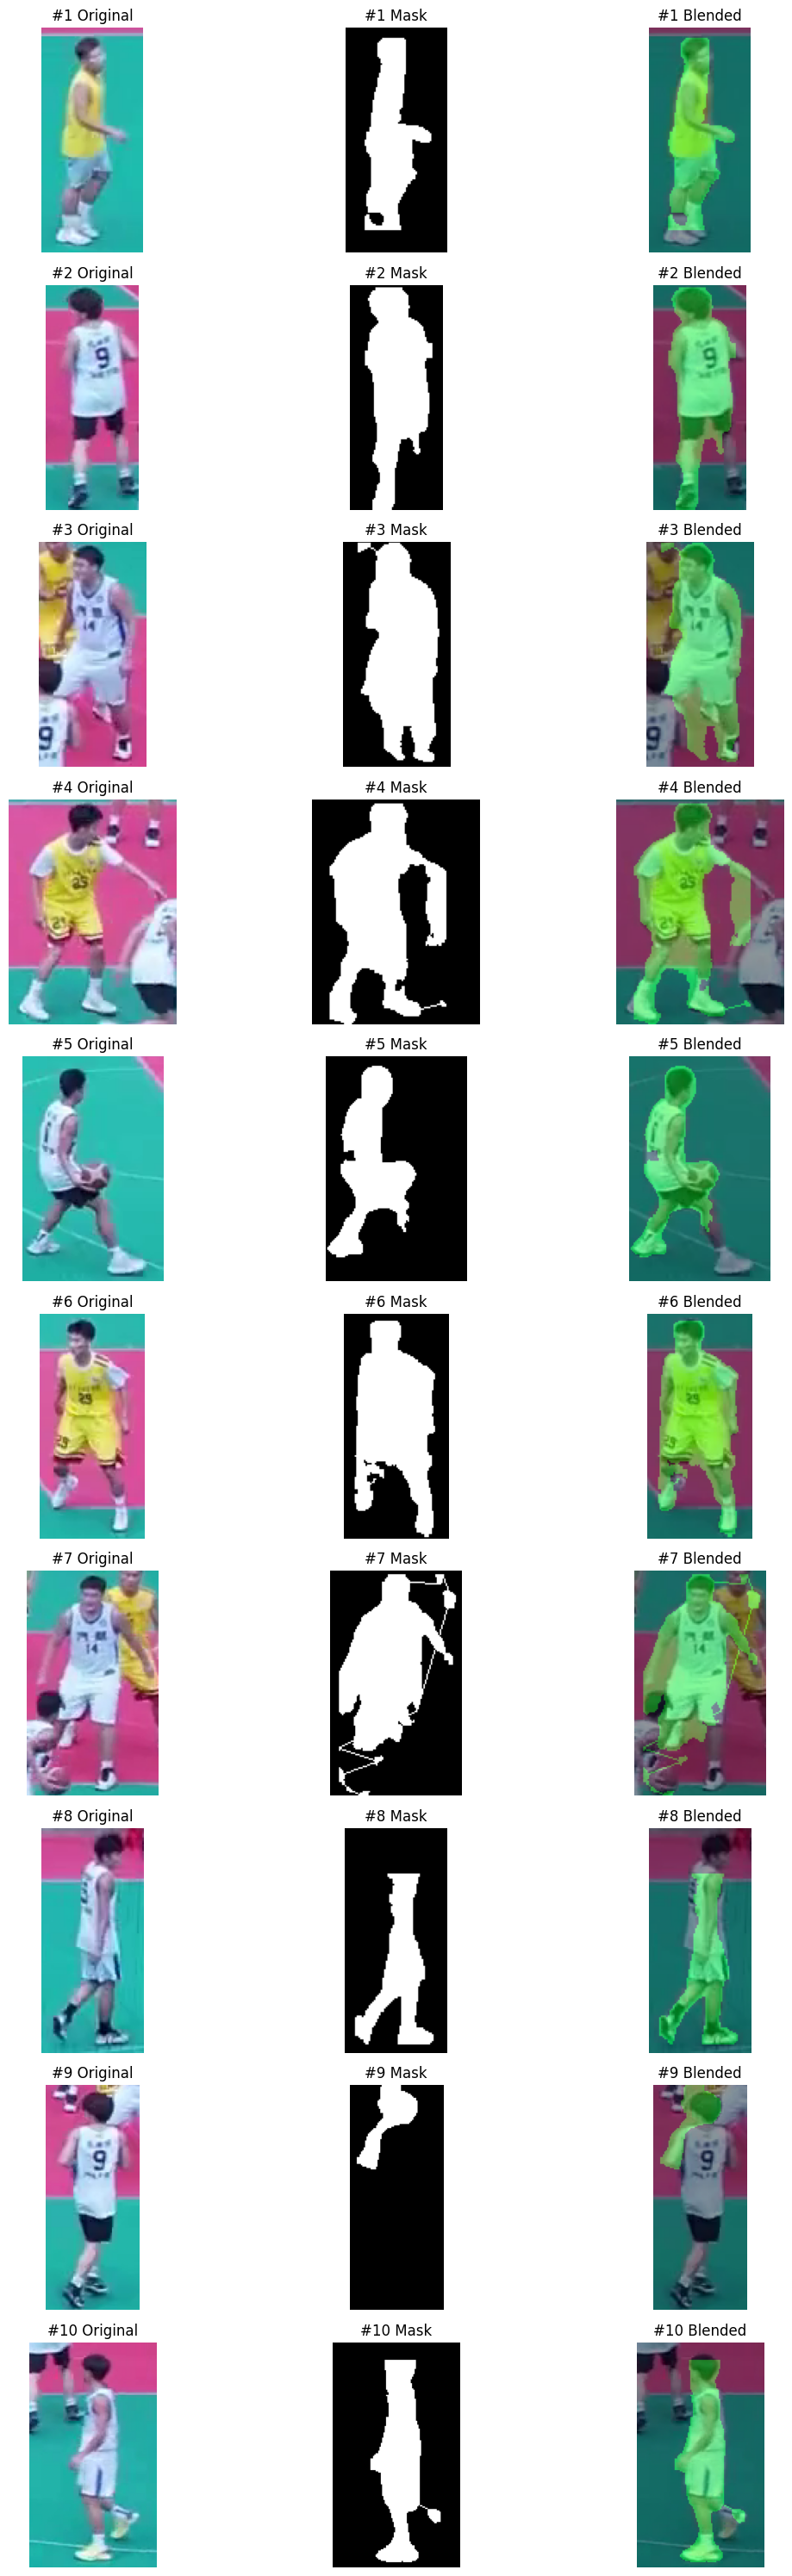

In [34]:
from components.visualization.team import plot_masks

plot_masks(tc.sample_detections, num_to_plot=10)

## 6. Render output video

Write a video with team-coloured bounding boxes overlaid on every frame.

In [35]:
from components.visualization.team import render_clustered_video

render_clustered_video(VIDEO_PATH, detections, OUTPUT_VIDEO)

Writing video:   0%|          | 3/900 [00:00<01:45,  8.53it/s]

Writing video: 100%|██████████| 900/900 [00:55<00:00, 16.21it/s]


Saved clustered video to team_clustering_result.mp4


## 7. Preview a frame from the result

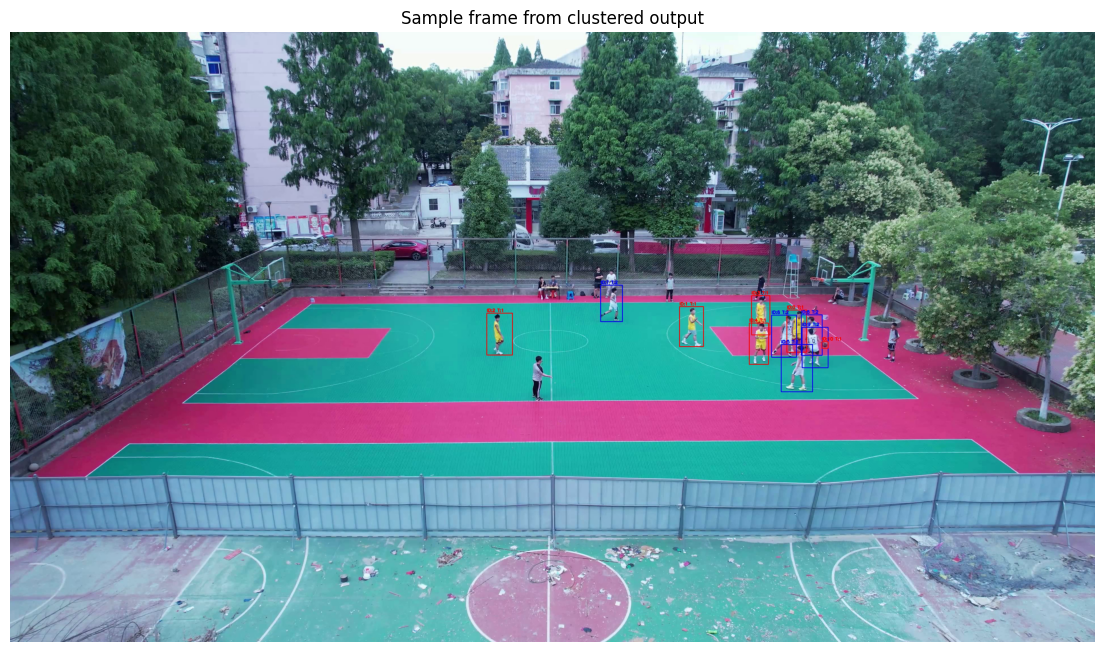

In [36]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(OUTPUT_VIDEO)
cap.set(cv2.CAP_PROP_POS_FRAMES, 50)
ret, frame = cap.read()
cap.release()

if ret:
    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Sample frame from clustered output")
    plt.show()